## Extended Data Fig. 6a

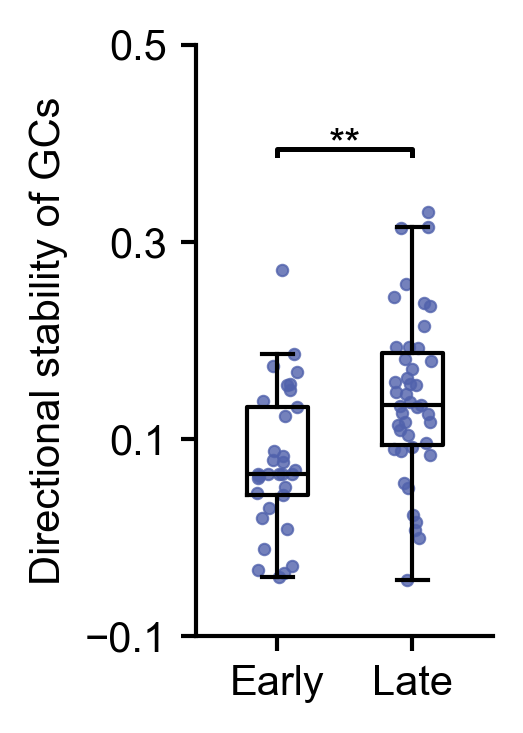

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../Results4Plots/directional stability_GCs_matched.csv").copy()
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Env"] == "VR")
    & (df["Stage"].isin(["early", "late"]))
    & (df["Value"].notna())
].copy()

colorVR = np.array([81, 98, 172]) / 255.0

xpos = {
    "early": 1,
    "late": 2
}

rng = np.random.default_rng(0)
jitter_width = 0.3

fig, ax = plt.subplots(figsize=(1.6, 2.3), dpi=300)

for stage in ["early", "late"]:
    y = df.loc[df["Stage"] == stage, "Value"].to_numpy(dtype=float)
    y = y[np.isfinite(y)]

    if y.size == 0:
        continue

    x0 = xpos[stage]
    jitter = (rng.random(y.size) - 0.5) * jitter_width

    ax.scatter(
        x0 + jitter,
        y,
        s=7.5,
        marker="o",
        facecolors=colorVR,
        edgecolors=colorVR,
        linewidths=0.5,
        alpha=0.8,
        zorder=1
    )

    ax.boxplot(
        y,
        positions=[x0],
        widths=0.45,
        showfliers=False,
        patch_artist=False,
        boxprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whiskerprops=dict(color="k", linewidth=1),
        capprops=dict(color="k", linewidth=1)
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Directional stability of GCs", fontsize=10, fontname="Arial")
ax.set_xticks([1, 2])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

y = df["Value"].max() + gap + 0.05

ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(1.5, y + h + text_offset - 0.02, "**", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.set_ylim(-0.1, 0.5)
ax.set_yticks([-0.1, 0.1, 0.3, 0.5])
ax.set_xlim(0.4, 2.6)

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 6b

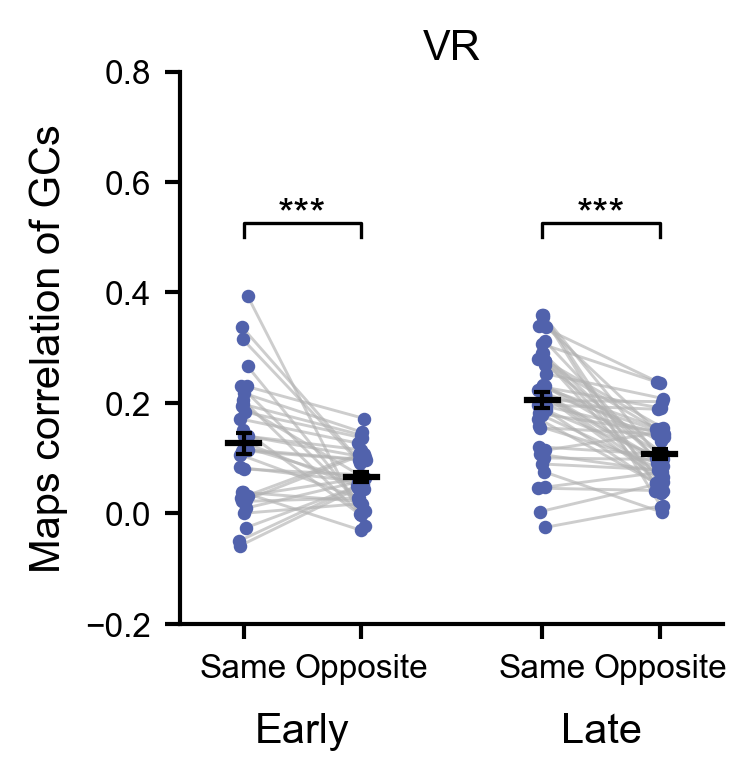

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Results4Plots/directional stability_GCs_matched_Corrdifference.csv")

for col in ["Animal", "Stage", "Environment"]:
    df[col] = df[col].astype("string").str.strip().str.strip("'\"")

for col in ["Trial", "rSame", "rOpposite"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[
    (df["Environment"] == "VR")
    & (df["Stage"].isin(["early", "late"]))
].dropna(subset=["Animal", "Trial", "rSame", "rOpposite"]).copy()

colorVR = np.array([81, 98, 172]) / 255.0

xpos = {
    ("early", "rSame"): 1.0,
    ("early", "rOpposite"): 2.3,
    ("late", "rSame"): 4.3,
    ("late", "rOpposite"): 5.6
}

rng = np.random.default_rng(1)
jitter_width = 0.1

fig, ax = plt.subplots(figsize=(2.4, 2.5), dpi=300)

for stage in ["early", "late"]:
    sub = df[df["Stage"] == stage]

    if sub.empty:
        continue

    x_same_base = xpos[(stage, "rSame")]
    x_opp_base = xpos[(stage, "rOpposite")]

    for _, row in sub.iterrows():
        jitter = (rng.random() - 0.5) * jitter_width
        x_same = x_same_base + jitter
        x_opp = x_opp_base + jitter

        ax.plot(
            [x_same, x_opp],
            [row["rSame"], row["rOpposite"]],
            color="0.70",
            linewidth=0.7,
            alpha=0.65,
            zorder=1
        )

        ax.scatter(
            [x_same, x_opp],
            [row["rSame"], row["rOpposite"]],
            s=7.5,
            marker="o",
            facecolors=colorVR,
            edgecolors=colorVR,
            linewidths=0.5,
            zorder=3
        )

    for measure in ["rSame", "rOpposite"]:
        y = sub[measure].to_numpy(dtype=float)
        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        mean_y = np.mean(y)
        sem_y = np.std(y, ddof=1) / np.sqrt(y.size)
        x0 = xpos[(stage, measure)]

        ax.plot([x0 - 0.17, x0 + 0.17], [mean_y, mean_y], color="k", linewidth=1.5, zorder=5)
        ax.errorbar(x0, mean_y, yerr=sem_y, fmt="none", ecolor="k", elinewidth=1, capsize=2, capthick=1, zorder=4)

def add_sig_bar(x1, x2, y, text):
    h = 0.025
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="k", linewidth=0.8, clip_on=False)
    ax.text((x1 + x2) / 2, y + 0.005, text, ha="center", va="bottom", fontsize=10, fontname="Arial")

add_sig_bar(1.0, 2.3, 0.5, "***")
add_sig_bar(4.3, 5.6, 0.5, "***")

ax.set_xlim(0.3, 6.3)
ax.set_xticks([1.0, 2.3, 4.3, 5.6])
ax.set_xticklabels(["Same", "Opposite", "Same", "Opposite"], fontsize=6, fontname="Arial")

ax.text(1.65, -0.16, "Early", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=10, fontname="Arial")
ax.text(4.95, -0.16, "Late", transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=10, fontname="Arial")

ax.set_ylabel("Maps correlation of GCs", fontsize=10, fontname="Arial")
ax.set_ylim(-0.2, 0.8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1, labelsize=8)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_title("VR", fontsize=10, fontname="Arial", pad=3)

plt.tight_layout(pad=0.3)
plt.show()